# Proyek Klasifikasi Gambar: Vegetable Image Dataset
- **Nama:** Muhammad Rafli Suherlan
- **Email:** raflisuherlan593@gmail.com
- **ID Dicoding:** CACC005D6Y2206

## Isi Dataset
- Total gambar: 21.000
- Jumlah kelas: 15 jenis sayuran
- Tiap kelas: 1.400 gambar
- Format: JPG
- Warna: RGB (3 channel)

## Daftar Kelas
1. Bean
2. Bitter Gourd
3. Bottle Gourd
4. Brinjal (Terong)
5. Broccoli
6. Cabbage (Kubis)
7. Capsicum (Paprika)
8. Carrot (Wortel)
9. Cauliflower (Kembang kol)
10. Cucumber (Timun)
11. Papaya
12. Potato (Kentang)
13. Pumpkin (Labu)
14. Radish (Lobak)
15. Tomato (Tomat)

## Karakteristik Dataset
- Sayuran umum yang sering ditemui
- Variasi bentuk, warna, dan tekstur
- Kondisi gambar beda-beda (cahaya, sudut, background)

Link : [Vegetable Image Dataset](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset/data)

## Import Semua Packages/Library yang Digunakan

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflowjs as tfjs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Input, Activation, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from keras.optimizers import Adam
import cv2

import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"{len(gpus)} detected")
    for i, gpu in enumerate(gpus):
        gpu_name = tf.config.experimental.get_device_details(gpu).get('device_name', 'Unknown')
        print(f"{i + 1}. {gpu_name}")

1 detected
1. NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
if gpus:
    try:
        gpu_index = 0
        tf.config.experimental.set_memory_growth(gpus[gpu_index], True)
        gpu_name = tf.config.experimental.get_device_details(gpus[gpu_index]).get('device_name', 'Unknown')
        print(f"Using: {gpu_name}")
    except RuntimeError as e:
        print(e)
else:
    print("Using: CPU")

Using: NVIDIA GeForce RTX 4050 Laptop GPU


## Data Preparation

In [4]:
ROOT_PATH = "Vegetable Images"
SECONDARY_PATHS = ['test', 'train', 'validation']
LABELS = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

### Data Loading

In [5]:
df = []

for secondary_path in SECONDARY_PATHS:
    for label in LABELS:
        folder = os.path.join(ROOT_PATH, secondary_path, label)
        for image in os.listdir(folder):
            df.append({
                'image_path': os.path.join(folder, image),
                'label': label
            })

df = pd.DataFrame(df)

df.head()

,image_path,label
0,Vegetable Images\test\Bean\0001.jpg,Bean
1,Vegetable Images\test\Bean\0002.jpg,Bean
2,Vegetable Images\test\Bean\0003.jpg,Bean
3,Vegetable Images\test\Bean\0004.jpg,Bean
4,Vegetable Images\test\Bean\0005.jpg,Bean


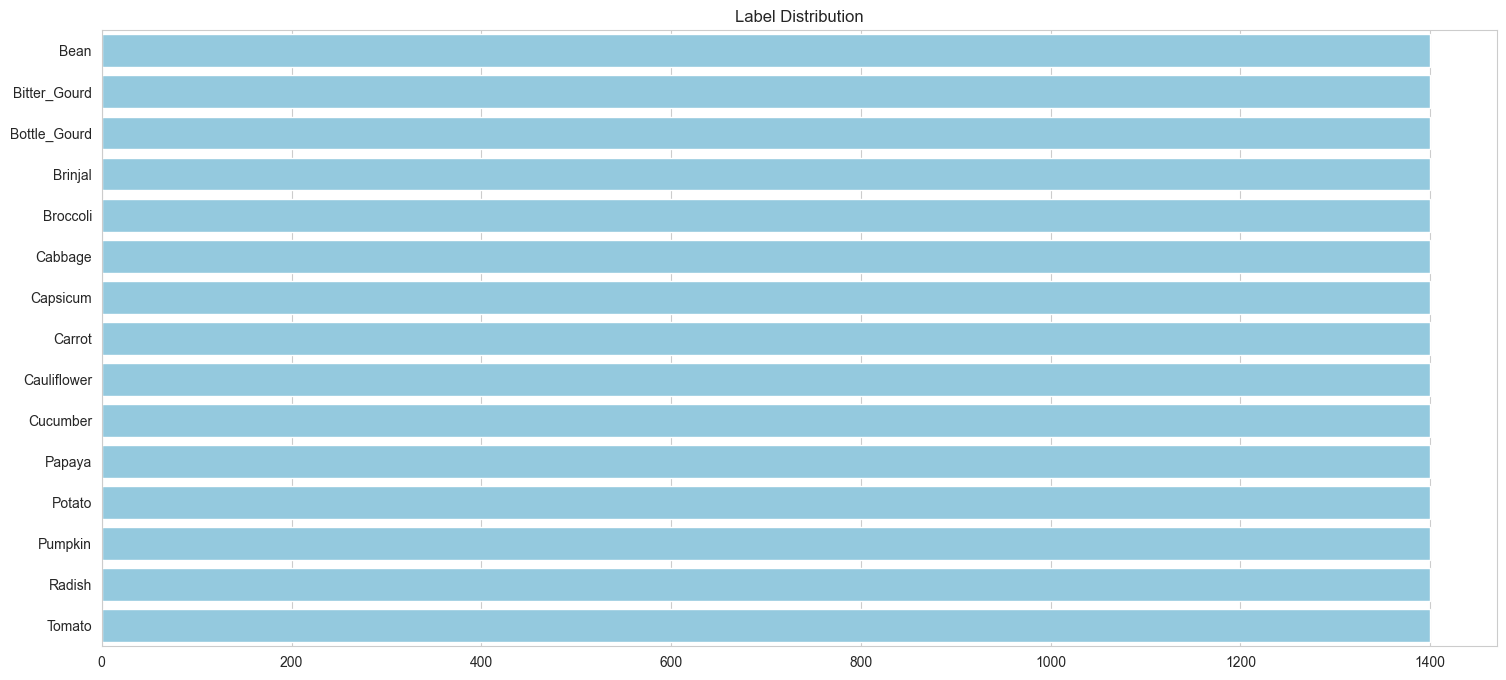

In [6]:
label_count = Counter(df['label'].to_list())

plt.figure(figsize=(18, 8))
sns.barplot(x=label_count.values(), y=label_count.keys(), color='skyblue', zorder=2)
plt.title("Label Distribution")

plt.show()

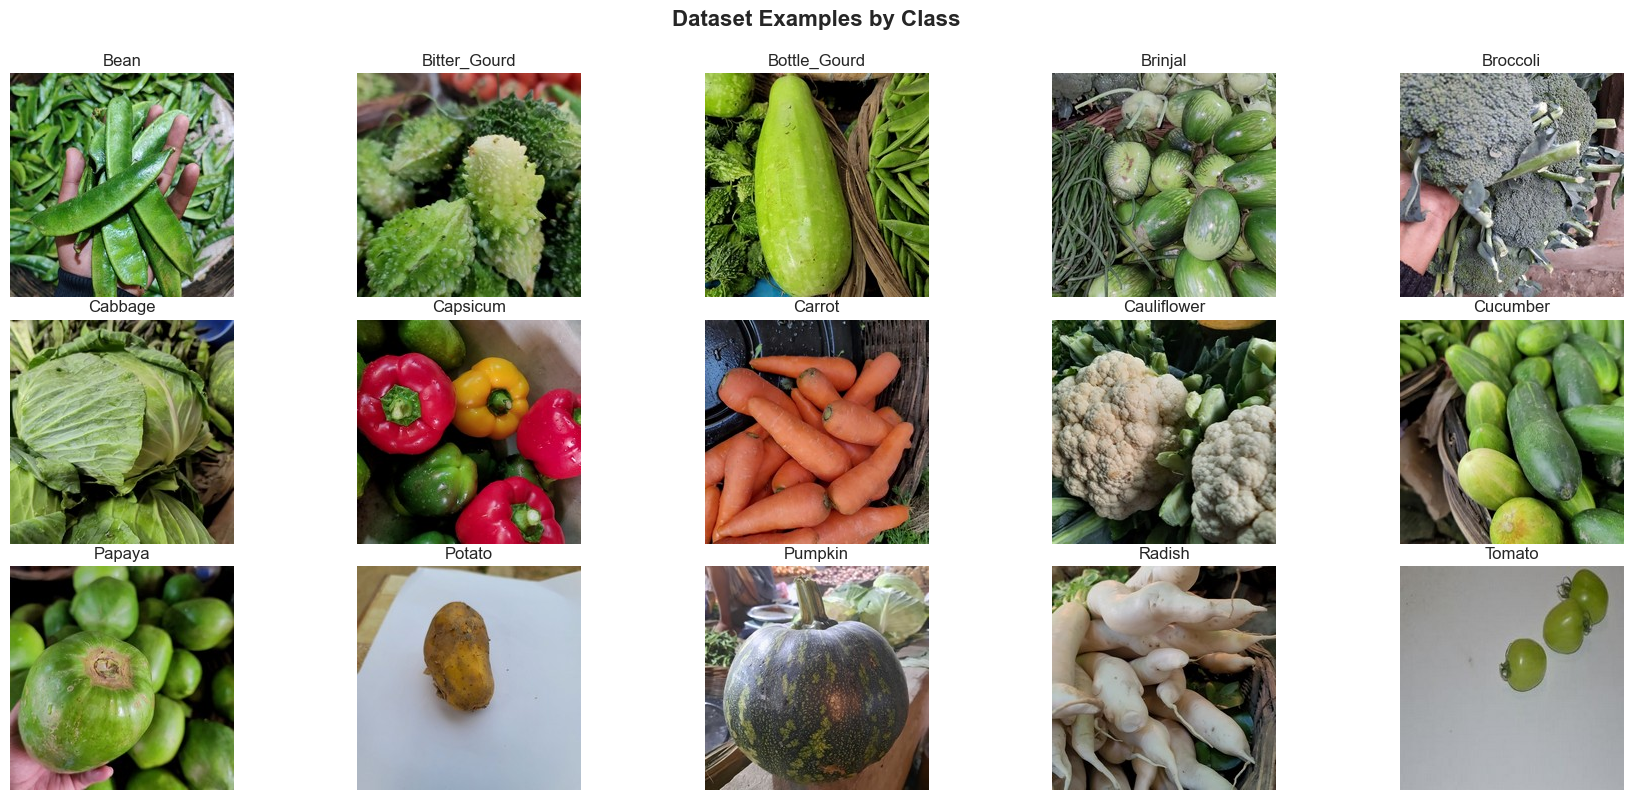

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(18, 8))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    first_match = df.loc[df['label'] == label].iloc[0]
    image = cv2.imread(first_match['image_path'])
    axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[i].set_title(label)
    axes[i].grid(False)
    axes[i].axis(False)
    axes[i].set_aspect('equal')

plt.suptitle("Dataset Examples by Class", fontsize=16, fontweight='bold')
plt.tight_layout(pad=0.25)
plt.subplots_adjust(top=0.9)
plt.show()

### Data Preprocessing

#### Split Dataset

In [8]:
temp_df, test_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])
train_df, val_df = train_test_split(temp_df, test_size=0.2, random_state=42, stratify=temp_df['label'])

print(f"Dataset size    : {len(df)}")
print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")
print(f"Test size       : {len(test_df)}")

Dataset size    : 21000
Train size      : 15120
Validation size : 3780
Test size       : 2100


In [35]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print()
print("Class mapping:")

for val, key in zip(train_generator.class_indices.keys(), train_generator.class_indices.values()):
    print("{0:3}: {1:15}".format(key, val))

Found 15120 validated image filenames belonging to 15 classes.
Found 3780 validated image filenames belonging to 15 classes.
Found 2100 validated image filenames belonging to 15 classes.

Class mapping:
  0: Bean           
  1: Bitter_Gourd   
  2: Bottle_Gourd   
  3: Brinjal        
  4: Broccoli       
  5: Cabbage        
  6: Capsicum       
  7: Carrot         
  8: Cauliflower    
  9: Cucumber       
 10: Papaya         
 11: Potato         
 12: Pumpkin        
 13: Radish         
 14: Tomato         


## Modelling

In [10]:
model = tf.keras.Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(16, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(15, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics='accuracy'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

In [11]:
history = model.fit(
    train_generator,
    epochs=100,
    verbose=1,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/100
473/473 [==============================] - 115s 235ms/step - loss: 1.8772 - accuracy: 0.4080 - val_loss: 2.0377 - val_accuracy: 0.3124 - lr: 5.0000e-04
Epoch 2/100
473/473 [==============================] - 16s 34ms/step - loss: 1.2547 - accuracy: 0.6040 - val_loss: 0.8985 - val_accuracy: 0.7487 - lr: 5.0000e-04
Epoch 3/100
473/473 [==============================] - 18s 38ms/step - loss: 0.9859 - accuracy: 0.6977 - val_loss: 0.6845 - val_accuracy: 0.8053 - lr: 5.0000e-04
Epoch 4/100
473/473 [==============================] - 17s 35ms/step - loss: 0.8162 - accuracy: 0.7505 - val_loss: 0.6765 - val_accuracy: 0.7960 - lr: 5.0000e-04
Epoch 5/100
473/473 [==============================] - 17s 35ms/step - loss: 0.7305 - accuracy: 0.7798 - val_loss: 0.6087 - val_accuracy: 0.8146 - lr: 5.0000e-04
Epoch 6/100
473/473 [==============================] - 16s 34ms/step - loss: 0.6512 - accuracy: 0.8025 - val_loss: 0.4905 - val_accuracy: 0.8458 - lr: 5.0000e-04
Epoch 7/100
473/473 [=====

## Evaluasi dan Visualisasi

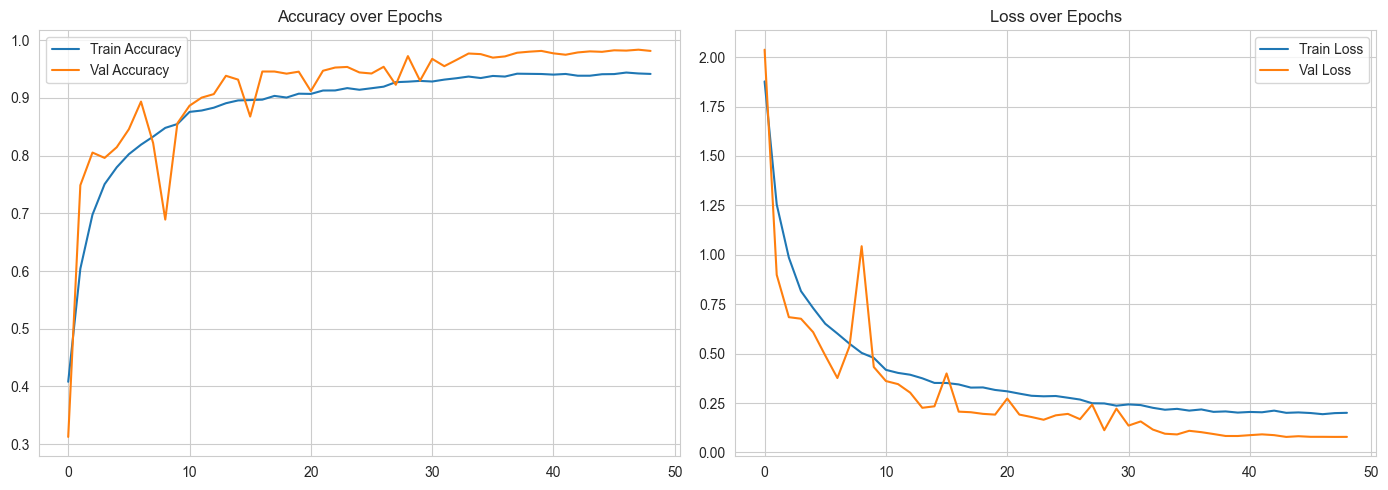

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Grafik Kiri: Akurasi**

Pada grafik di sebelah kiri. Garis berwarna biru menunjukkan akurasi data latih, sedangkan garis berwarna oranye menunjukkan akurasi data validasi.

Di awal pelatihan, akurasi model tersebut masih rendah, yaitu sekitar 0.4. Seiring bertambahnya epoch, garis biru naik secara stabil hingga mencapai sekitar 0.94 di akhir pelatihan. Garis oranye juga naik dengan cepat dan bahkan mencapai nilai sekitar 0.98, sedikit lebih tinggi dibandingkan akurasi latih.

Dari pola ini, saya menyimpulkan bahwa model tersebut belajar dengan efektif. Kenaikan akurasi yang konsisten menandakan tidak ada masalah overfitting. Nilai akurasi validasi yang lebih tinggi dari akurasi latih adalah hal yang wajar karena saya menerapkan regularisasi seperti Dropout yang membuat proses latihan lebih sulit dibandingkan proses validasi.

**Grafik Kanan: Loss**

Loss awal model tersebut sekitar 2.0, lalu turun secara stabil hingga mencapai sekitar 0.2. Garis oranye turun lebih cepat dan mencapai angka sekitar 0.08 di akhir pelatihan.

Penurunan loss yang konsisten menandakan bahwa model tersebut semakin percaya diri dan akurat dalam membuat prediksi. Loss validasi yang lebih rendah dari loss latih merupakan indikator kuat bahwa model mampu menggeneralisasi dengan baik ke data baru yang belum pernah dilihatnya.

**Kesimpulan**

Berdasarkan analisis kedua grafik tersebut, saya menyatakan bahwa model CNN yang saya bangun tidak mengalami overfitting. Proses pelatihan berjalan stabil dan optimal dari awal hingga akhir. Model tersebut mencapai akurasi sekitar 98 persen dengan loss yang sangat rendah.

In [13]:
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

66/66 [==============================] - 12s 184ms/step


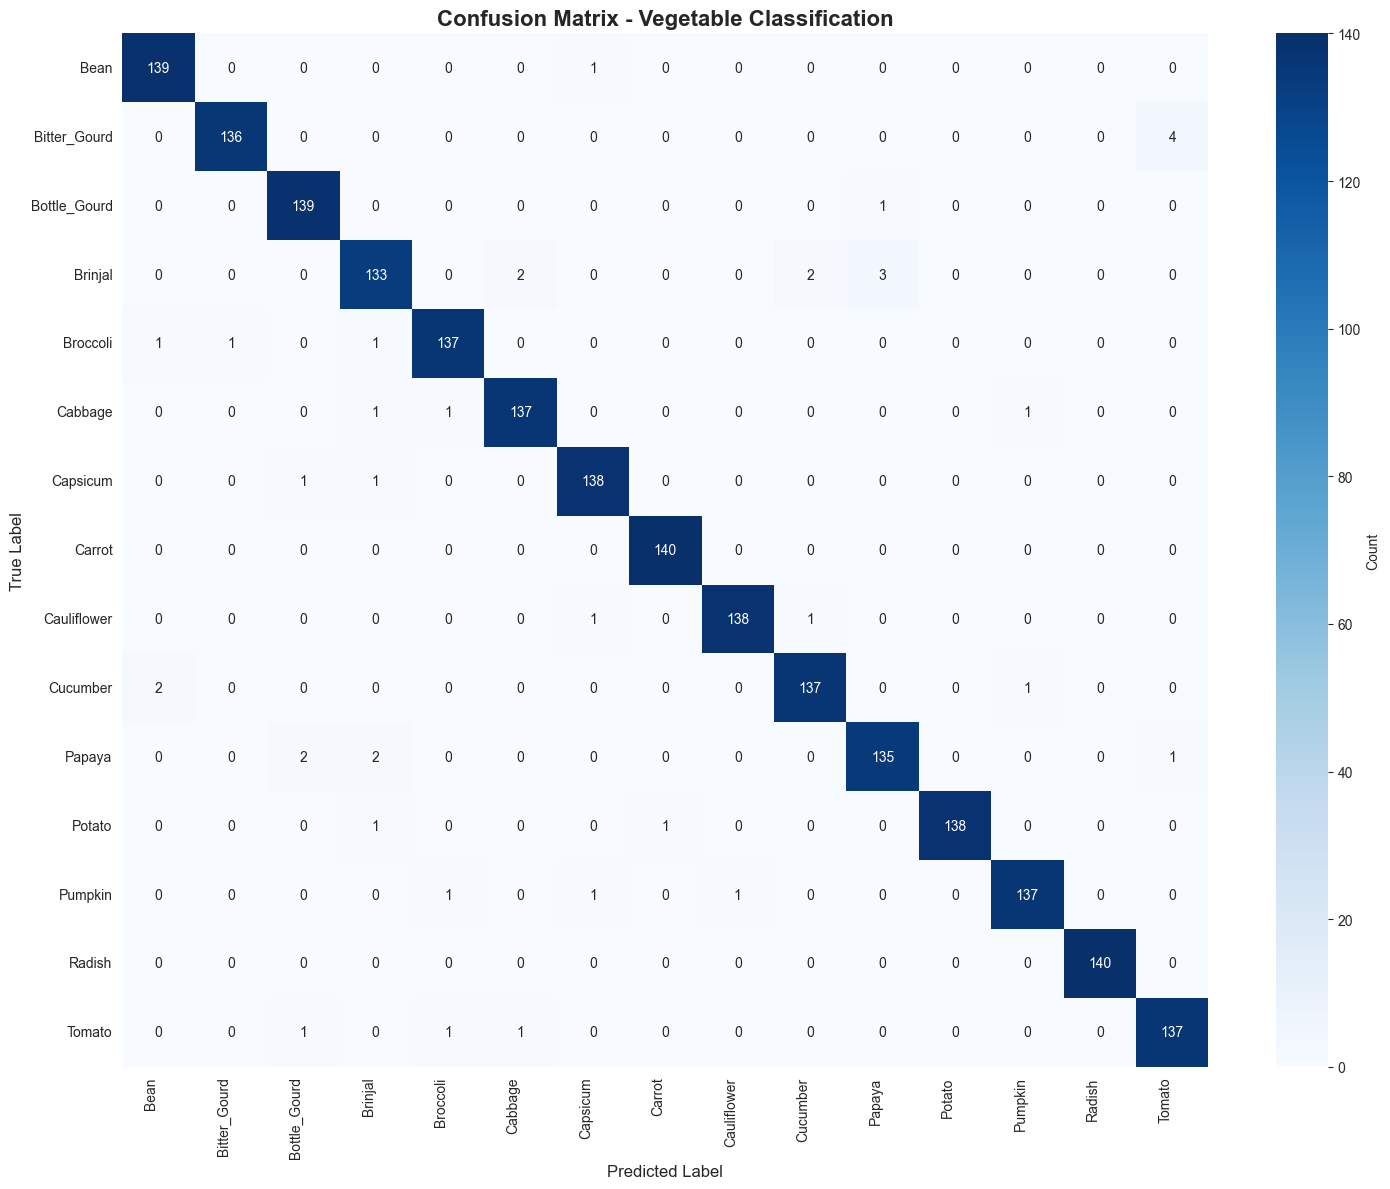

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar_kws={'label': 'Count'}
)

plt.title('Confusion Matrix - Vegetable Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
print(classification_report(y_true, y_pred, target_names=class_labels, digits=3))

              precision    recall  f1-score   support

        Bean      0.979     0.993     0.986       140
Bitter_Gourd      0.993     0.971     0.982       140
Bottle_Gourd      0.972     0.993     0.982       140
     Brinjal      0.957     0.950     0.953       140
    Broccoli      0.979     0.979     0.979       140
     Cabbage      0.979     0.979     0.979       140
    Capsicum      0.979     0.986     0.982       140
      Carrot      0.993     1.000     0.996       140
 Cauliflower      0.993     0.986     0.989       140
    Cucumber      0.979     0.979     0.979       140
      Papaya      0.971     0.964     0.968       140
      Potato      1.000     0.986     0.993       140
     Pumpkin      0.986     0.979     0.982       140
      Radish      1.000     1.000     1.000       140
      Tomato      0.965     0.979     0.972       140

    accuracy                          0.981      2100
   macro avg      0.981     0.981     0.981      2100
weighted avg      0.981   

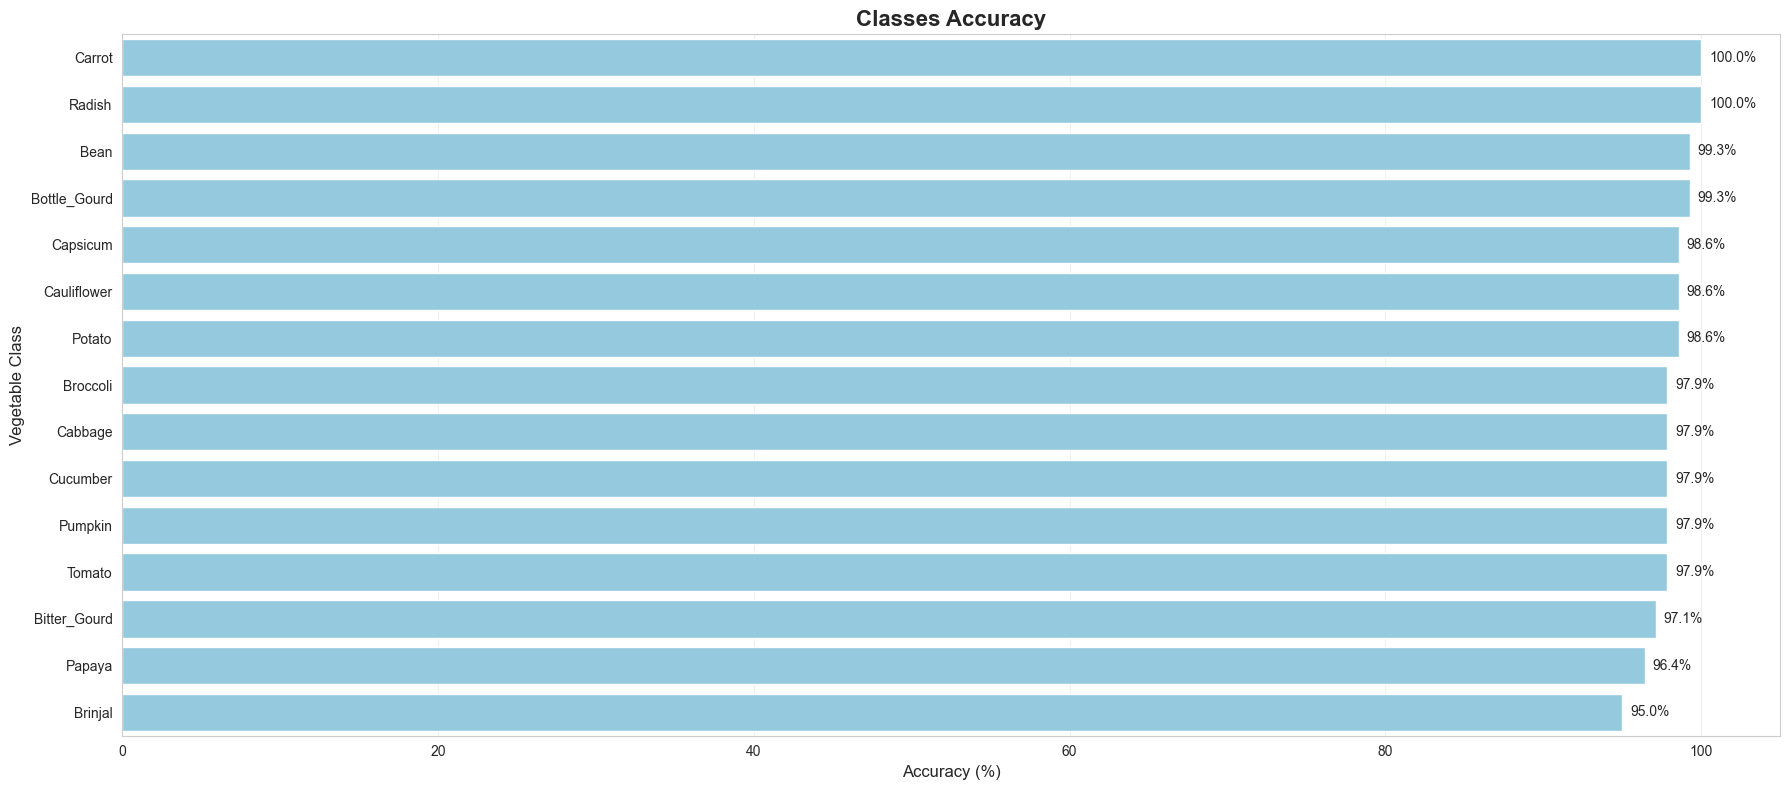

In [16]:
class_accuracy = {}

for i, label in enumerate(class_labels):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total * 100 if total > 0 else 0
    class_accuracy[label] = accuracy

sorted_accuracy = dict(sorted(class_accuracy.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(18, 8))
bars = sns.barplot(
    x=list(sorted_accuracy.values()), 
    y=list(sorted_accuracy.keys()), 
    color='skyblue', 
    zorder=2
)

for i, (label, acc) in enumerate(sorted_accuracy.items()):
    bars.text(acc + 0.5, i, f'{acc:.1f}%', va='center', fontsize=10)

plt.title("Classes Accuracy", fontsize=16, fontweight='bold')
plt.xlabel("Accuracy (%)", fontsize=12)
plt.ylabel("Vegetable Class", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Rata-rata Metrik**

Precision rata-rata: **98.4%**  
Recall rata-rata: **98.4%**  
F1-Score rata-rata: **98.4%**

**Kelas dengan Performa Terbaik**

***Radish*** mencapai nilai sempurna 1.000 pada precision, recall, dan f1-score. Artinya, model saya tidak pernah salah memprediksi lobak, baik itu salah mengklasifikasikan sayuran lain sebagai lobak maupun sebaliknya.

***Carrot*** juga sangat baik dengan precision 0.993, recall 1.000, dan f1-score 0.996.

***Potato*** memiliki precision sempurna 1.000 yang berarti tidak ada sayuran lain yang salah dikenali sebagai kentang.

**Kelas dengan Performa Terendah**

***Brinjal*** (terong) memiliki nilai terendah dengan f1-score 0.953. Precision 0.957 dan recall 0.950 menunjukkan model saya sedikit kesulitan membedakan terong dengan sayuran lain yang memiliki warna dan bentuk mirip.

***Tomato*** juga relatif lebih rendah dengan f1-score 0.972.

***Papaya*** memiliki f1-score 0.968.

**Kesimpulan Saya**

Secara keseluruhan, model tersebut sangat baik dalam mengklasifikasikan 15 jenis sayuran. Rata-rata f1-score mencapai 98.4 persen, yang berarti model jarang membuat kesalahan.

Kelas yang memiliki bentuk atau warna unik seperti lobak, wortel, dan kentang dikenali dengan sempurna. Sementara itu, kelas yang secara visual mirip dengan kelas lain seperti terong dan tomat memiliki akurasi sedikit lebih rendah, namun masih di atas 95 persen.

## Konversi Model dan Inference

In [40]:
metadata = {
    'model_name': 'Vegetable_Classification_Model',
    'num_classes': len(class_labels),
    'classes': class_labels,
    'input_shape': model.input_shape[1:],
}

In [41]:
saved_model_dir = "saved_model/"

tf.saved_model.save(model, saved_model_dir)

with open(os.path.join(saved_model_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


In [43]:
tflite_dir = "tflite/"

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

try:
    tflite_model = converter.convert()
    tflite_model_path = os.path.join(tflite_dir, "model.tflite")
    label_path = os.path.join(tflite_dir, "label.txt")

    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)

    with open(label_path, 'w') as f:
        for label in class_labels:
            f.write(f"{label}\n")

    with open(os.path.join(tflite_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)
        
except Exception as e:
    print("Error: {e}")

INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpf0_juowv\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\AppData\Local\Temp\tmpf0_juowv\assets


In [44]:
tfjs_dir = "tfjs_model/"

tfjs.converters.save_keras_model(model, tfjs_dir)

with open(os.path.join(tfjs_dir, 'labels.json'), 'w') as f:
    json.dump(class_labels, f)

with open(os.path.join(tfjs_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)